In [29]:
import pandas as pd 
import numpy as np
from pathlib import Path

In [30]:
import os 
from pathlib import Path 
path=Path.cwd().parent

In [31]:
(path/'data/train_flood.csv').exists()

True

In [32]:
df=pd.read_csv(path/'data/train_flood.csv')
df1=pd.read_csv(path/'data/test_flood.csv')

In [33]:
df.head()

,row_id,month,day_of_year,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,...,slope_scaled,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,rain_soilmoisture_interaction,rain_urban_interaction,rain_slope_interaction,rain_basinsize_interaction,uparea_rain_interaction,streamflow_tomorrow_cumecs
0,0,2,3,51.84180,-0.554512,-0.406627,-1.649524,0.0,0.0,0.0,...,-0.564147,0.638676,-0.347207,-1.043051,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,51.435061
1,1,2,3,570.75726,-0.594236,-5.728960,0.206959,0.0,0.0,0.0,...,-0.184717,0.039940,-0.347207,0.183875,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,565.028190
2,2,2,3,45.45640,-1.113376,-0.192057,-1.649524,0.0,0.0,0.0,...,-0.564147,-1.066421,-0.347207,-1.043051,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,45.264231
3,3,2,3,405.39710,-0.729036,-2.480840,0.769118,0.0,0.0,0.0,...,0.068236,2.278693,4.526986,-1.533821,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,402.916149
4,4,2,3,2289.59030,-1.284924,-16.203800,-0.256761,0.0,0.0,0.0,...,-0.311194,-0.728005,-0.347207,0.183875,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,2273.386393


In [34]:
df.shape

(2571055, 34)

In [35]:
df.columns

Index(['row_id', 'month', 'day_of_year', 'streamflow_today_cumecs',
       'streamflow_anomaly_zscore', 'flow_rate_of_change',
       'flow_velocity_km_per_day', 'antecedent_rain_3d_sum',
       'antecedent_rain_7d_sum', 'antecedent_rain_15d_sum',
       'antecedent_rain_30d_sum', 'antecedent_rain_60d', 'antecedent_rain_ewm',
       'rainfall_anomaly_zscore', 'upstream_rain_mean_scaled',
       'upstream_rain_weighted_scaled', 'upstream_rain_lagged_dist_sink',
       'soil_saturation_score', 'antecedent_saturation_interaction',
       'is_post_monsoon_saturated', 'monsoon_intensity',
       'monsoon_cumulative_rain', 'dist_to_outlet_scaled',
       'upstream_area_scaled', 'slope_scaled', 'slope_uav_scaled',
       'forest_cover_scaled', 'urban_cover_scaled',
       'rain_soilmoisture_interaction', 'rain_urban_interaction',
       'rain_slope_interaction', 'rain_basinsize_interaction',
       'uparea_rain_interaction', 'streamflow_tomorrow_cumecs'],
      dtype='str')

In [36]:
df.duplicated().sum(), df.isnull().sum()

(np.int64(0),
 row_id                               0
 month                                0
 day_of_year                          0
 streamflow_today_cumecs              0
 streamflow_anomaly_zscore            0
 flow_rate_of_change                  0
 flow_velocity_km_per_day             0
 antecedent_rain_3d_sum               0
 antecedent_rain_7d_sum               0
 antecedent_rain_15d_sum              0
 antecedent_rain_30d_sum              0
 antecedent_rain_60d                  0
 antecedent_rain_ewm                  0
 rainfall_anomaly_zscore              0
 upstream_rain_mean_scaled            0
 upstream_rain_weighted_scaled        0
 upstream_rain_lagged_dist_sink       0
 soil_saturation_score                0
 antecedent_saturation_interaction    0
 is_post_monsoon_saturated            0
 monsoon_intensity                    0
 monsoon_cumulative_rain              0
 dist_to_outlet_scaled                0
 upstream_area_scaled                 0
 slope_scaled             

In [37]:
Id=df1['row_id']

In [38]:
df.drop('row_id',axis=1,inplace=True)
df1.drop('row_id',axis=1,inplace=True)

In [39]:
df.head()

,month,day_of_year,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,antecedent_rain_30d_sum,...,slope_scaled,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,rain_soilmoisture_interaction,rain_urban_interaction,rain_slope_interaction,rain_basinsize_interaction,uparea_rain_interaction,streamflow_tomorrow_cumecs
0,2,3,51.84180,-0.554512,-0.406627,-1.649524,0.0,0.0,0.0,0.0,...,-0.564147,0.638676,-0.347207,-1.043051,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,51.435061
1,2,3,570.75726,-0.594236,-5.728960,0.206959,0.0,0.0,0.0,0.0,...,-0.184717,0.039940,-0.347207,0.183875,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,565.028190
2,2,3,45.45640,-1.113376,-0.192057,-1.649524,0.0,0.0,0.0,0.0,...,-0.564147,-1.066421,-0.347207,-1.043051,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,45.264231
3,2,3,405.39710,-0.729036,-2.480840,0.769118,0.0,0.0,0.0,0.0,...,0.068236,2.278693,4.526986,-1.533821,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,402.916149
4,2,3,2289.59030,-1.284924,-16.203800,-0.256761,0.0,0.0,0.0,0.0,...,-0.311194,-0.728005,-0.347207,0.183875,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,2273.386393


In [40]:
df['month_cos'] = np.cos(2*np.pi*df['month']/12 )
df['month_sin'] = np.sin(2*np.pi*df['month']/12 )

df1['month_cos'] = np.cos(2*np.pi*df1['month']/12 )
df1['month_sin'] = np.sin(2*np.pi*df1['month']/12 )

In [41]:
df.drop('month',axis=1,inplace=True)
df1.drop('month',axis=1,inplace=True)

In [42]:
df['dayofyear_cos'] = np.cos(2*np.pi*df['day_of_year']/365 )
df['dayofyear_sin'] = np.sin(2*np.pi*df['day_of_year']/365)

df1['dayofyear_cos'] = np.cos(2*np.pi*df1['day_of_year']/365 )
df1['dayofyear_sin'] = np.sin(2*np.pi*df1['day_of_year']/365)

In [43]:
df.drop('day_of_year',axis=1,inplace=True)
df1.drop('day_of_year',axis=1,inplace=True)

In [44]:
df.head()

,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,antecedent_rain_30d_sum,antecedent_rain_60d,antecedent_rain_ewm,...,rain_soilmoisture_interaction,rain_urban_interaction,rain_slope_interaction,rain_basinsize_interaction,uparea_rain_interaction,streamflow_tomorrow_cumecs,month_cos,month_sin,dayofyear_cos,dayofyear_sin
0,51.84180,-0.554512,-0.406627,-1.649524,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,51.435061,0.5,0.866025,0.998667,0.05162
1,570.75726,-0.594236,-5.728960,0.206959,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,565.028190,0.5,0.866025,0.998667,0.05162
2,45.45640,-1.113376,-0.192057,-1.649524,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,45.264231,0.5,0.866025,0.998667,0.05162
3,405.39710,-0.729036,-2.480840,0.769118,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,402.916149,0.5,0.866025,0.998667,0.05162
4,2289.59030,-1.284924,-16.203800,-0.256761,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,2273.386393,0.5,0.866025,0.998667,0.05162


In [45]:
import matplotlib.pyplot as plt 

In [46]:
# single merged interaction
df['merged_rain_interaction'] = df[[
    'rain_soilmoisture_interaction', 
    'rain_urban_interaction', 
    'rain_slope_interaction', 
    'rain_basinsize_interaction',
    'uparea_rain_interaction',
    'antecedent_saturation_interaction'
]].mean(axis=1)

df1['merged_rain_interaction'] = df1[[
    'rain_soilmoisture_interaction', 
    'rain_urban_interaction', 
    'rain_slope_interaction', 
    'rain_basinsize_interaction',
    'uparea_rain_interaction',
    'antecedent_saturation_interaction'
]].mean(axis=1)

In [47]:
# single merged scaled
df['upstream_rain_weighted' ]=(df['upstream_rain_mean_scaled']*0.6)+(df['upstream_rain_weighted_scaled']*0.4)
df1['upstream_rain_weighted' ]=(df1['upstream_rain_mean_scaled']*0.6)+(df1['upstream_rain_weighted_scaled']*0.4)

In [48]:
drop_cols=[
    'rain_soilmoisture_interaction', 
    'rain_urban_interaction', 
    'rain_slope_interaction', 
    'rain_basinsize_interaction',
    'uparea_rain_interaction',
    'antecedent_saturation_interaction',
    
    'upstream_rain_mean_scaled',
    'upstream_rain_weighted_scaled'
]

In [49]:
df.drop(columns=drop_cols,inplace=True)
df1.drop(columns=drop_cols,inplace=True)
df.head()

,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,antecedent_rain_30d_sum,antecedent_rain_60d,antecedent_rain_ewm,...,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,streamflow_tomorrow_cumecs,month_cos,month_sin,dayofyear_cos,dayofyear_sin,merged_rain_interaction,upstream_rain_weighted
0,51.84180,-0.554512,-0.406627,-1.649524,0.0,0.0,0.0,0.0,0.0,0.0,...,0.638676,-0.347207,-1.043051,51.435061,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854
1,570.75726,-0.594236,-5.728960,0.206959,0.0,0.0,0.0,0.0,0.0,0.0,...,0.039940,-0.347207,0.183875,565.028190,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854
2,45.45640,-1.113376,-0.192057,-1.649524,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.066421,-0.347207,-1.043051,45.264231,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854
3,405.39710,-0.729036,-2.480840,0.769118,0.0,0.0,0.0,0.0,0.0,0.0,...,2.278693,4.526986,-1.533821,402.916149,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854
4,2289.59030,-1.284924,-16.203800,-0.256761,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.728005,-0.347207,0.183875,2273.386393,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854


In [50]:
df.drop('flow_rate_of_change',axis=1, inplace= True)
df1.drop('flow_rate_of_change',axis=1,inplace=True)

In [51]:
# giving higher weight to recent rain
df['antecedent_total'] = (df['antecedent_rain_3d_sum'] * 0.4) + (df['antecedent_rain_7d_sum'] * 0.3) + (df['antecedent_rain_15d_sum'] * 0.1)+(df['antecedent_rain_30d_sum']*0.05)+(df['antecedent_rain_60d']*0.05)+(df['antecedent_rain_ewm']*0.1)
df1['antecedent_total'] = (df1['antecedent_rain_3d_sum'] * 0.4) + (df1['antecedent_rain_7d_sum'] * 0.3) + (df1['antecedent_rain_15d_sum'] * 0.1)+(df1['antecedent_rain_30d_sum']*0.05)+(df1['antecedent_rain_60d']*0.05)+(df1['antecedent_rain_ewm']*0.1)

In [52]:
antecedent_cols=[
    'antecedent_rain_3d_sum',
    'antecedent_rain_7d_sum',
    'antecedent_rain_15d_sum',
    'antecedent_rain_30d_sum',
    'antecedent_rain_60d',
    'antecedent_rain_ewm' 
]

In [54]:
df.drop(columns=antecedent_cols,inplace=True)
df1.drop(columns=antecedent_cols,inplace=True)
df.head()

,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_velocity_km_per_day,rainfall_anomaly_zscore,upstream_rain_lagged_dist_sink,soil_saturation_score,is_post_monsoon_saturated,monsoon_intensity,monsoon_cumulative_rain,dist_to_outlet_scaled,...,forest_cover_scaled,urban_cover_scaled,streamflow_tomorrow_cumecs,month_cos,month_sin,dayofyear_cos,dayofyear_sin,merged_rain_interaction,upstream_rain_weighted,antecedent_total
0,51.84180,-0.554512,-1.649524,-0.274649,-0.231412,0.0,0,0.0,0.0,1.393736,...,-0.347207,-1.043051,51.435061,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0
1,570.75726,-0.594236,0.206959,-0.220278,-0.231412,0.0,0,0.0,0.0,0.114867,...,-0.347207,0.183875,565.028190,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0
2,45.45640,-1.113376,-1.649524,-0.311483,-0.231412,0.0,0,0.0,0.0,-1.348137,...,-0.347207,-1.043051,45.264231,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0
3,405.39710,-0.729036,0.769118,-0.228279,-0.231412,0.0,0,0.0,0.0,-0.265436,...,4.526986,-1.533821,402.916149,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0
4,2289.59030,-1.284924,-0.256761,-0.282414,-0.231412,0.0,0,0.0,0.0,-1.402705,...,-0.347207,0.183875,2273.386393,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0


In [55]:
plt.figure(figsize=(20,9))
cor = df.corr()
sns.heatmap(cor,annot=True,fmt='.2f',cmap='coolwarm',mask=np.triu(np.ones_like(cor,dtype=bool),k=0))
plt.show()

NameError: name 'sns' is not defined

<Figure size 2000x900 with 0 Axes>

In [ ]:
df['merged_upstream']=(df['merged_rain_interaction']*0.6)+(df['upstream_rain_weighted']*0.4)
df1['merged_upstream']=(df1['merged_rain_interaction']*0.6)+(df1['upstream_rain_weighted']*0.4)

In [ ]:
df.drop(columns={'merged_rain_interaction','upstream_rain_weighted'},axis=1,inplace=True)
df1.drop(columns={'merged_rain_interaction','upstream_rain_weighted'},axis=1,inplace=True)
df.head()

,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_velocity_km_per_day,rainfall_anomaly_zscore,upstream_rain_lagged_dist_sink,soil_saturation_score,is_post_monsoon_saturated,monsoon_intensity,monsoon_cumulative_rain,dist_to_outlet_scaled,...,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,streamflow_tomorrow_cumecs,month_cos,month_sin,dayofyear_cos,dayofyear_sin,antecedent_total,merged_upstream
0,51.84180,-0.554512,-1.649524,-0.274649,-0.231412,0.0,0,0.0,0.0,1.393736,...,0.638676,-0.347207,-1.043051,51.435061,0.5,0.866025,0.998667,0.05162,0.0,-0.437748
1,570.75726,-0.594236,0.206959,-0.220278,-0.231412,0.0,0,0.0,0.0,0.114867,...,0.039940,-0.347207,0.183875,565.028190,0.5,0.866025,0.998667,0.05162,0.0,-0.437748
2,45.45640,-1.113376,-1.649524,-0.311483,-0.231412,0.0,0,0.0,0.0,-1.348137,...,-1.066421,-0.347207,-1.043051,45.264231,0.5,0.866025,0.998667,0.05162,0.0,-0.437748
3,405.39710,-0.729036,0.769118,-0.228279,-0.231412,0.0,0,0.0,0.0,-0.265436,...,2.278693,4.526986,-1.533821,402.916149,0.5,0.866025,0.998667,0.05162,0.0,-0.437748
4,2289.59030,-1.284924,-0.256761,-0.282414,-0.231412,0.0,0,0.0,0.0,-1.402705,...,-0.728005,-0.347207,0.183875,2273.386393,0.5,0.866025,0.998667,0.05162,0.0,-0.437748


In [56]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [57]:
X=df.drop('streamflow_tomorrow_cumecs',axis=1)
y=df['streamflow_tomorrow_cumecs']

In [58]:
split=int(df.shape[0]*0.8)

In [59]:
train=df.iloc[:split]
test=df.iloc[split:]

In [60]:
X_train=train.drop('streamflow_tomorrow_cumecs',axis=1)
y_train=train['streamflow_tomorrow_cumecs']

X_test=test.drop('streamflow_tomorrow_cumecs',axis=1)
y_test=test['streamflow_tomorrow_cumecs']

# Base error 

In [61]:
base=X_test['streamflow_today_cumecs']
mean_absolute_error(y_test,base),mean_squared_error(y_test,base)**.5,  r2_score(y_test, base)

(43.75593985437995, 140.80993250221957, 0.9956920809424377)

In [62]:
from sklearn.ensemble import RandomForestRegressor 
from xgboost import XGBRegressor 
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression, Ridge


ModuleNotFoundError: No module named 'catboost'

In [ ]:
models  = {
    'xgb' : XGBRegressor(
        n_estimators = 200,
        subsample = 0.8,
        max_depth = 8,
        n_jobs= -1
        ),
    'Linear_Regression' : LinearRegression(n_jobs=-1),
    'Ridge':Ridge(),
    'RandomForestRegressor':RandomForestRegressor(
        n_estimators=100,
        max_depth=8,
        max_features='sqrt',
        n_jobs=-1,
    ),
    'Catboost':CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function="RMSE",
        task_type="GPU",    
    )
}

In [ ]:
def training(Model, X_train,y_train,X_test,y_test):
    result = []
    saved_model = {}
    import time 
    
    for name,model in Model.items():
        start = time.perf_counter()
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
        
        mae = mean_absolute_error(y_test,y_pred)
        mse = mean_squared_error(y_test,y_pred)
        r2 = r2_score(y_test,y_pred)
        end = time.perf_counter()
        result.append({
            'model':name,
            'MAE':mae,
            "RMSE":mse**0.5,
            'R2_score/NSE':r2,
            'Time_taken(s)' : end- start
        })
        saved_model[name]=model
    return pd.DataFrame(result), saved_model

In [ ]:
result,saved_model = training(models ,X_train,y_train,X_test,y_test)

0:	learn: 1959.1781430	total: 20.2ms	remaining: 6.03s
1:	learn: 1776.1601297	total: 31.5ms	remaining: 4.69s
2:	learn: 1612.3788037	total: 41.7ms	remaining: 4.13s
3:	learn: 1465.4824719	total: 52.2ms	remaining: 3.86s
4:	learn: 1333.5372482	total: 63.3ms	remaining: 3.73s
5:	learn: 1216.0310923	total: 76.5ms	remaining: 3.75s
6:	learn: 1110.1206209	total: 89.1ms	remaining: 3.73s
7:	learn: 1016.1654196	total: 103ms	remaining: 3.77s
8:	learn: 931.1990666	total: 121ms	remaining: 3.92s
9:	learn: 856.1827837	total: 136ms	remaining: 3.93s
10:	learn: 789.9724829	total: 152ms	remaining: 4s
11:	learn: 730.9023884	total: 169ms	remaining: 4.06s
12:	learn: 674.4118643	total: 183ms	remaining: 4.03s
13:	learn: 625.9913175	total: 198ms	remaining: 4.05s
14:	learn: 579.9928652	total: 212ms	remaining: 4.03s
15:	learn: 543.7070040	total: 229ms	remaining: 4.07s
16:	learn: 509.3400786	total: 244ms	remaining: 4.06s
17:	learn: 477.5944113	total: 260ms	remaining: 4.08s
18:	learn: 450.8275689	total: 273ms	remainin

In [ ]:
result.sort_values('MAE')

,model,MAE,RMSE,R2_score/NSE,Time_taken(s)
0,xgb,30.597978,100.373795,0.997811,12.975490
4,Catboost,45.667578,127.791537,0.996452,4.792442
1,Linear_Regression,48.888301,136.831646,0.995932,0.683250
2,Ridge,48.888495,136.831833,0.995932,0.224197
3,RandomForestRegressor,122.387491,249.666737,0.986457,34.365753


In [ ]:
best_model = saved_model['xgb'] # G

In [ ]:
(pd.Series((best_model.feature_importances_), index = X_train.columns).sort_values(ascending= False) )

streamflow_today_cumecs           0.965557
monsoon_intensity                 0.012212
dist_to_outlet_scaled             0.005879
streamflow_anomaly_zscore         0.003885
dayofyear_cos                     0.002325
month_cos                         0.002198
upstream_area_scaled              0.001652
dayofyear_sin                     0.000882
slope_uav_scaled                  0.000838
merged_upstream                   0.000684
monsoon_cumulative_rain           0.000653
urban_cover_scaled                0.000483
soil_saturation_score             0.000475
slope_scaled                      0.000373
upstream_rain_lagged_dist_sink    0.000352
antecedent_total                  0.000346
flow_velocity_km_per_day          0.000346
forest_cover_scaled               0.000306
rainfall_anomaly_zscore           0.000280
month_sin                         0.000275
is_post_monsoon_saturated         0.000000
dtype: float32

<Axes: >

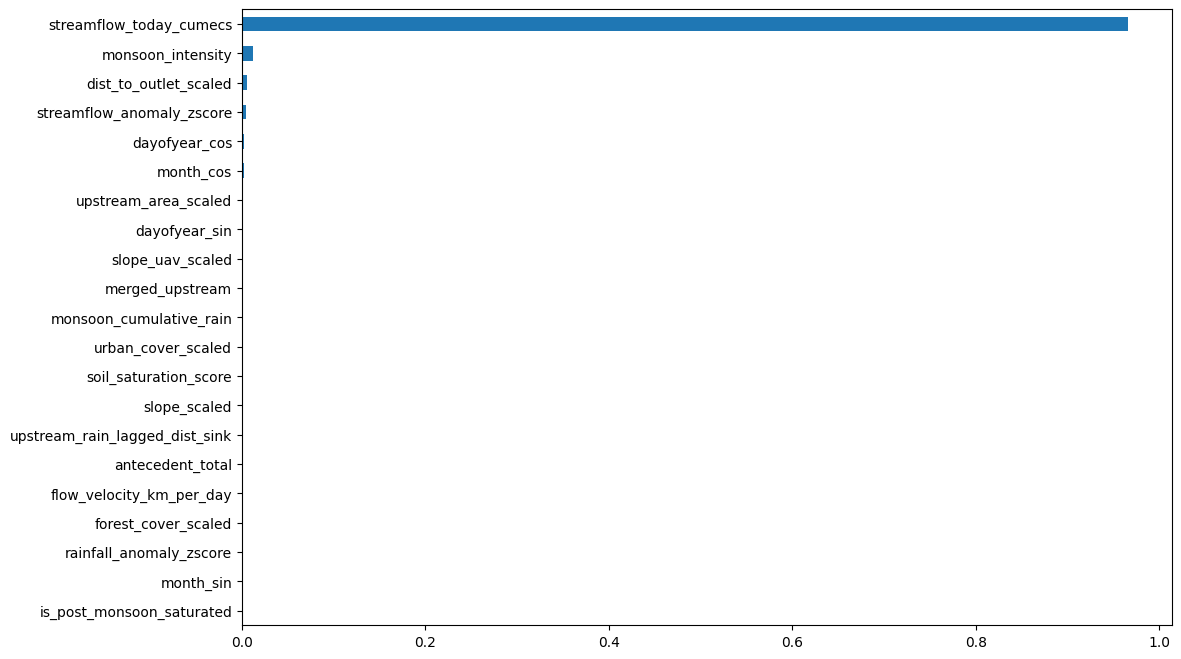

In [ ]:
plt.figure(figsize = (12,8))
(pd.Series((best_model.feature_importances_), index = X_train.columns).sort_values() ).plot(kind= 'barh')

In [ ]:
import joblib 
joblib.dump(best_model,'Xgb_model.pkl')

['Xgb_model.pkl']

In [ ]:
import joblib
feature_names = X_train.columns.tolist()
joblib.dump(
    feature_names,
    "features.pkl"
)

['features.pkl']

In [ ]:
sols=best_model.predict(df1)
sols=best_model.predict(df1)

In [ ]:
final_sol=(sols*0.5)+(sols1*0.5)

In [ ]:
submission=pd.DataFrame({
    'row_id':Id,
    'streamflow_tomorrow_cumecs':sols
})

In [ ]:
submission.to_csv('submission.csv',index=False)

In [ ]:
%pip freeze > requirements.txt


In [ ]:
df11=pd.read_csv(path/'data/train_flood.csv')
err = (
    df11["streamflow_today_cumecs"] +
    df11["flow_rate_of_change"] -
    df11["streamflow_tomorrow_cumecs"]
).abs()

print(err.describe())